# Chapter 6: The True Static Split (Train / Val / Test) & Hyperparameter Grid

This notebook implements the gold-standard Chronological Static Split (1500 days Train / 500 days Val / 500 days Test).
It loops through a grid of Neural Network configurations (architectures and learning rates). 
The model that achieves the lowest NLL on the Validation Set is selected as the winner. 
Finally, the winning NN and the Baseline are evaluated purely on the Out-Of-Sample Test Set.

In [66]:
import warnings
warnings.filterwarnings('ignore')

import sys

from datetime import date
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t

from density_forecasting.evaluation.metrics import block_ks_test
from density_forecasting.evaluation.metrics import evaluate_forecasts, kupiec_pof_test
from density_forecasting.models.neural_networks import generate_montecarlo
from density_forecasting.models.tf_neural_networks import create_cnn_sequences

# Import our optimized pipeline functions
from density_forecasting.evaluation.fast_pipeline import (
    read_data_features,
    extract_array,
    extract_df_nn,
    run_baseline,
    backtesting_baseline,
    initializate_nn_model,
    run_neural_networks,
    backtesting_neural_networks
)

# import warnings
# warnings.filterwarnings('ignore')

# import sys
# sys.path.append('..')
# import os

# from datetime import date
# import pandas as pd
# import numpy as np
# import tensorflow as tf
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import t

# from src.evaluation.metrics import block_ks_test, evaluate_forecasts, kupiec_pof_test
# from src.models.neural_networks import generate_montecarlo

# # Import optimized pipeline functions
# from src.evaluation.fast_pipeline import (
#     read_data_features, extract_array, extract_df_nn, run_baseline,
#     backtesting_baseline, initializate_nn_model, run_neural_networks,
#     backtesting_neural_networks
# )


## 1. Configuration & Tuning Grid

In [67]:

# df_features.columns

In [ ]:
# tickers = ['ARKK', 'USO', 'BTC-USD', 'SQM-B.SN', 'SPY', "TSLA", "DBK.DE"]
# tickers = ['ARKK', 'USO', 'SQM-B.SN', 'SPY', "TSLA", "DBK.DE"]
# tickers = ['QQQ',
#    ]


tickers = [
    'SPY', 
    'QQQ',
  #  'IWM',
  #  'XLE'
  #  'TLT',
  #   "TSLA", 
  #   'ARKK', 
  #   'USO', 
  #  #  'SQM-B.SN', 
  #  #  "DBK.DE", 
  #  'XLF',
  #  'EEM',
  #  'ECH',
  #  'NVDA'
   ]

# tickers = ['SPY']
# tickers = ['ARKK', 'USO', 'SQM-B.SN']

# tickers = ["SPY", "TSLA", "DBK.DE"]
# start_date = date(2010, 1, 1) # Earlier start date to get more data
start_date = date(2010, 4, 30) # Earlier start date to get more data
end_date = date(2025, 12, 31)

# columns_deep = ['vix_ratio', 'VIX']
columns_linear = ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt']
columns_deep = ['vix_ratio']


# 
# columns_deep = ['vix_ratio']

initial_epochs = 4001
MIN_DATA_ROWS = 2500 # 1500 Train, 500 Val, 500 Test = approx 10 years

# Hyperparameter Grid
# grid_columns_deep = [['vix_ratio'], ['vix_ratio', 'Feat_Volume_Shock'], ['vix_ratio', 'Feat_RSI_14'], ['vix_ratio', 'Feat_Volume_Shock', 'Feat_RSI_14']]
grid_columns_linear = [
                  #   ['returns_m1', 
                  #    'returns_m1_2', 
                  #    # 'vix_ratio'
                  #   ]
                    ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt', 
                     'returns_m1_2',
                     'Macro_USD_Trend',
                     'Macro_Credit_Stress',
                     # 'Copper_Trend'
                     
                     ],
      
                       ]
# df_features['returns_m2'] = df_features['returns'].shift(2)
#     df_features['returns_m3'] = df_features['returns'].shift(3)

#     df_features['returns_m1_2'] = df_features['returns_m1_2']**2
#     df_features['returns_m2_2'] = df_features['returns_m2_2']**2
#     df_features['returns_m3_2'] = df_features['returns_m3_2']**2

grid_columns_deep = [
                  # ['vix_ratio',
                  #    #  'returns_m1_2',
                  #    # 'returns_m2_2',
                  #    # 'returns_m3_2'
                  #    ],
                     # ['vix_ratio', 'Feat_Volume_Shock', 'returns_m1_2',],
                     ['vix_ratio', 'Macro_Rate_Shock'],
                     # ['vix_ratio', 'Feat_Volume_Shock', 'Feat_RSI_14'],


                     ]

# grid_columns_linear = [
#                        ['returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt']
#                        ]

# grid_model_classes = ['Linear', 'WideAndDeep']
# grid_model_classes = ['conv'] 
grid_model_classes = ['WideAndDeep']

grid_lrs = [0.02]
# grid_lrs = [0.015, 0.005]
# grid_lambda_regs = [0.5, 0.6]
grid_lambda_regs = [0.5, 1.0, 2.0]
# grid_lambda_regs = [0.01, 0.05, 0.1]




In [69]:
# print(len(baseline_prior_v['mu'][20:]), len(baseline_prior_v['mu'][:]))



STATIC SPLIT SHOWDOWN & TUNING: SPY
Fetching SPY data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2806 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 1.6735, ks_stat: 0.0863

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 1.6735 and KS Stat: 0.0863
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SUMM

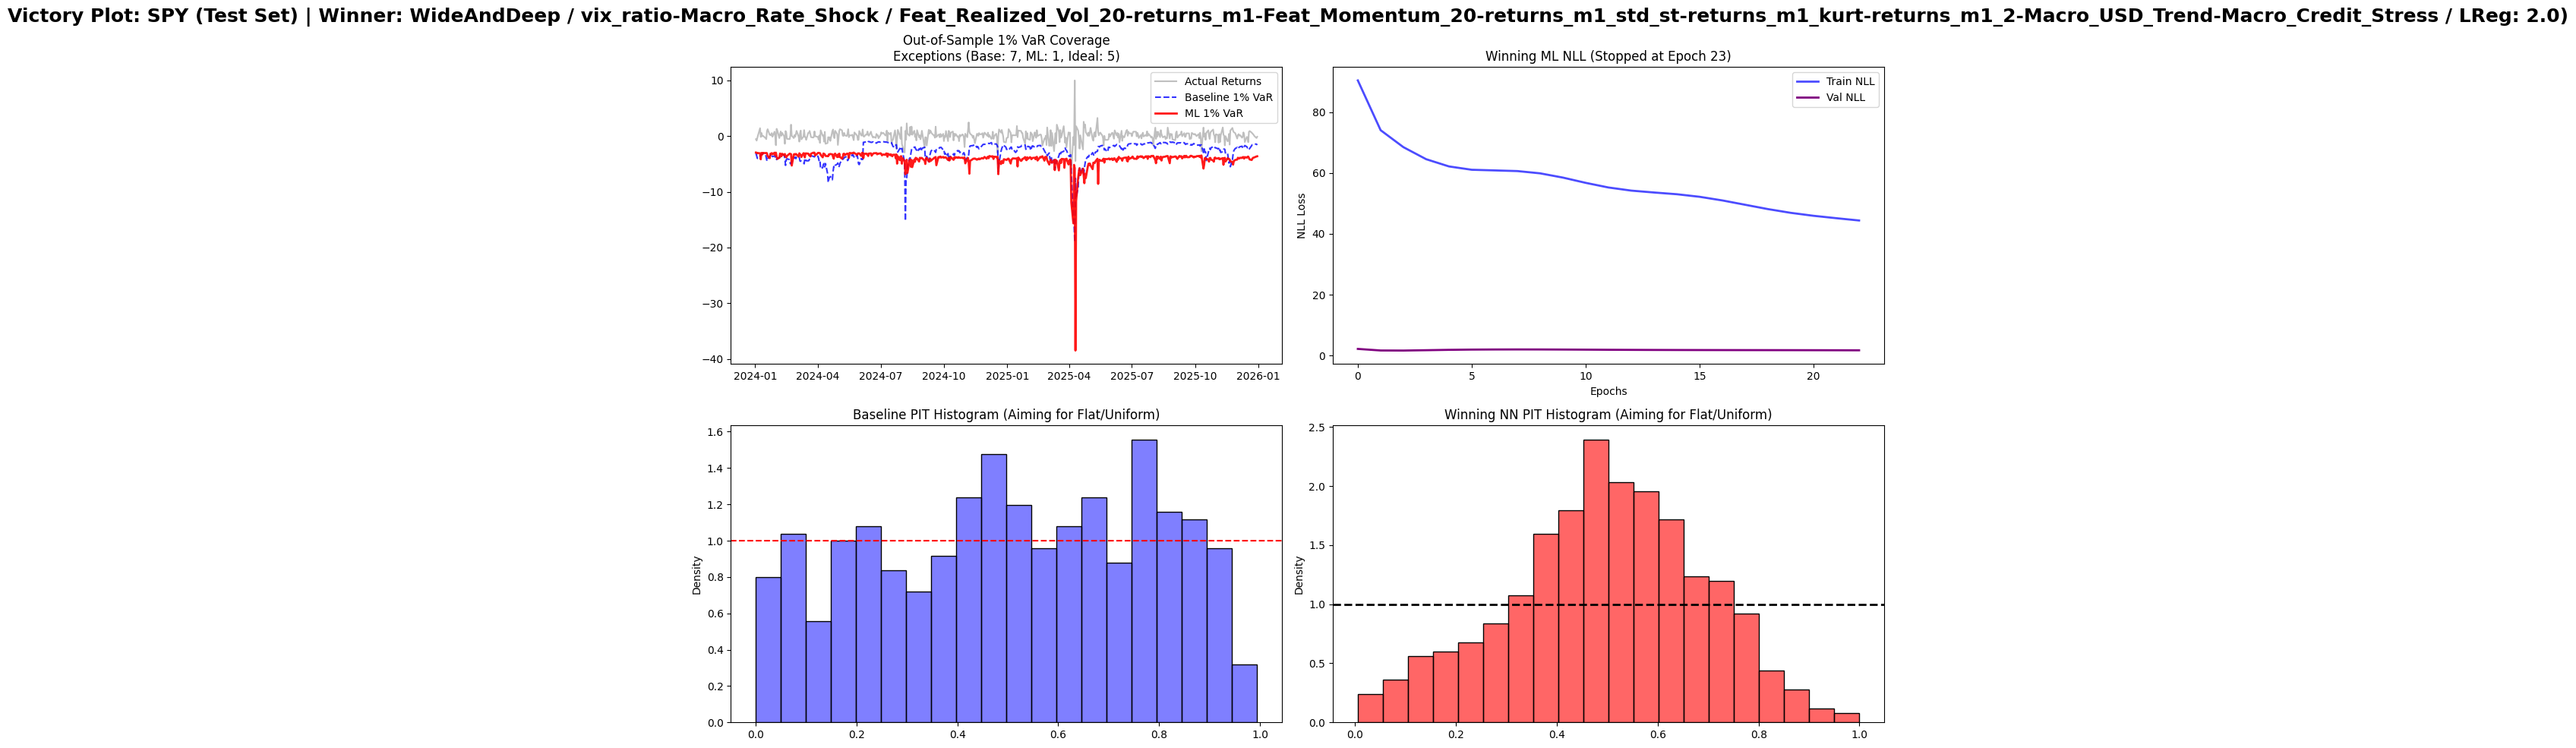


STATIC SPLIT SHOWDOWN & TUNING: QQQ
Fetching QQQ data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2806 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 1.9555, ks_stat: 0.0431

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 1.9555 and KS Stat: 0.0431
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SUMM

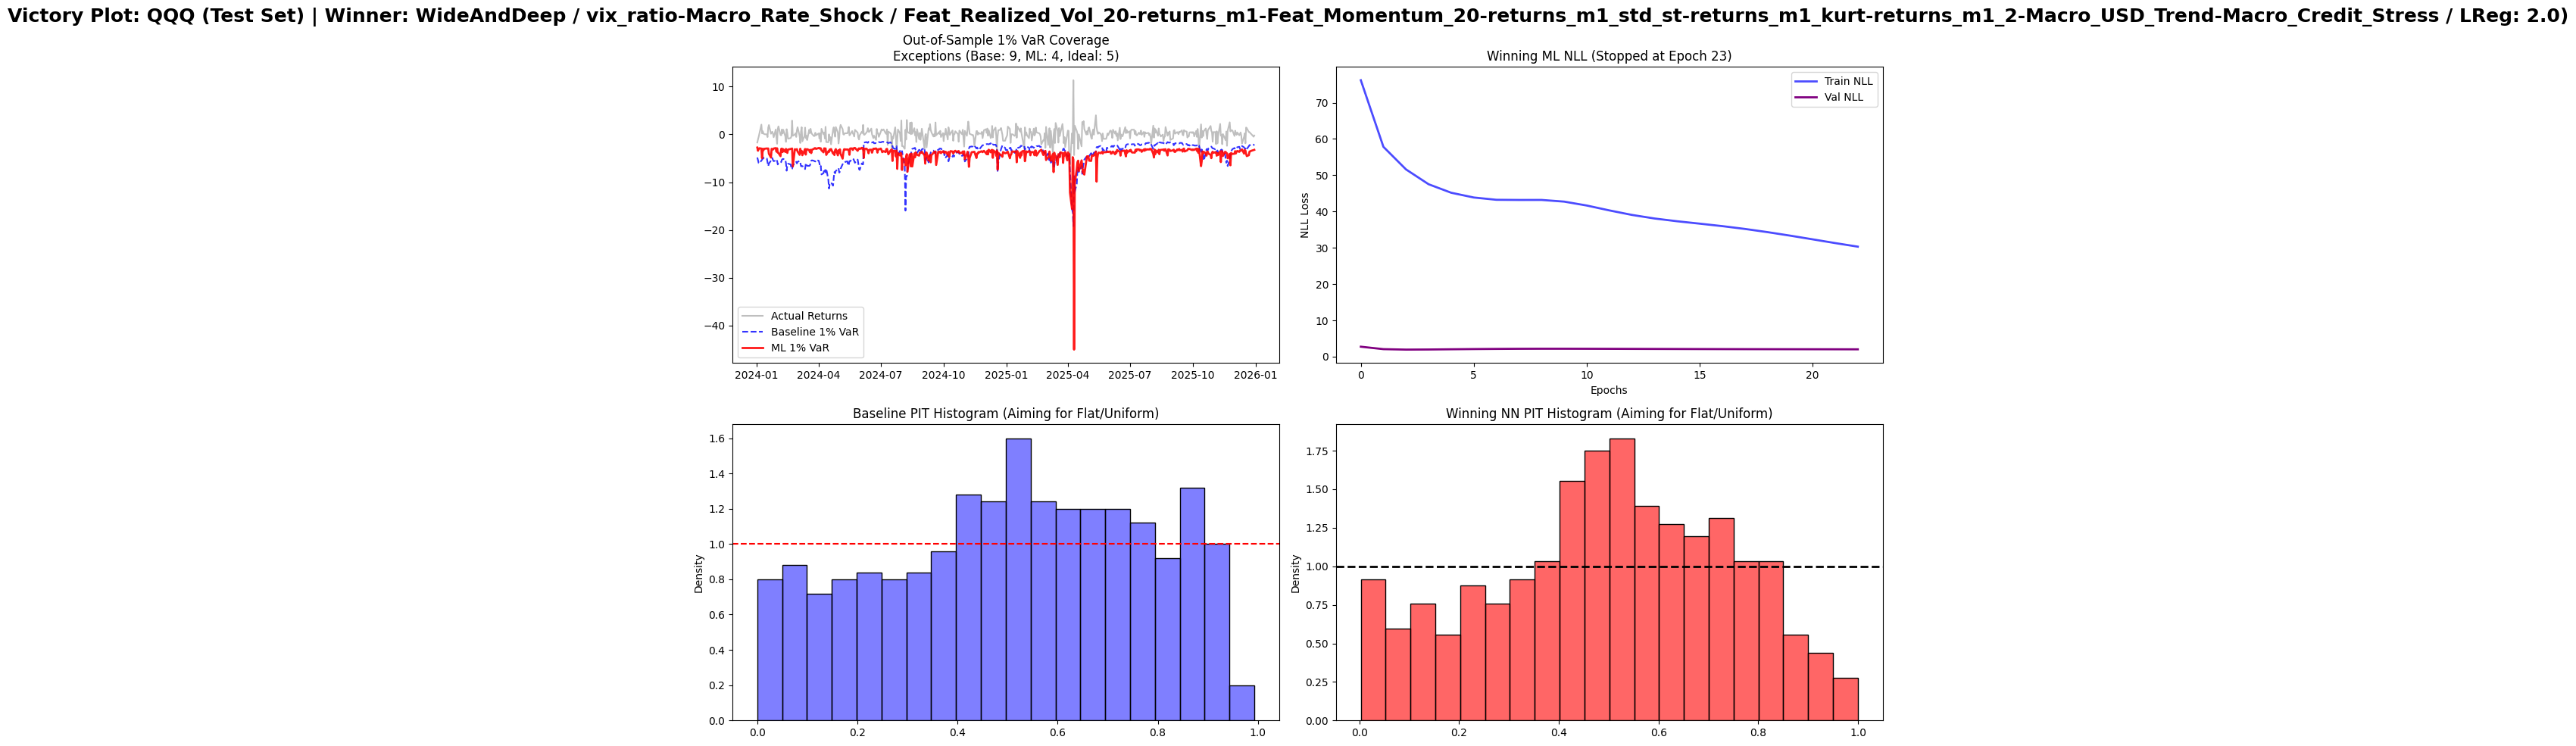


STATIC SPLIT SHOWDOWN & TUNING: IWM
Fetching IWM data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2806 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 1.8924, ks_stat: 0.0299

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 1.8924 and KS Stat: 0.0299
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SUMMAR

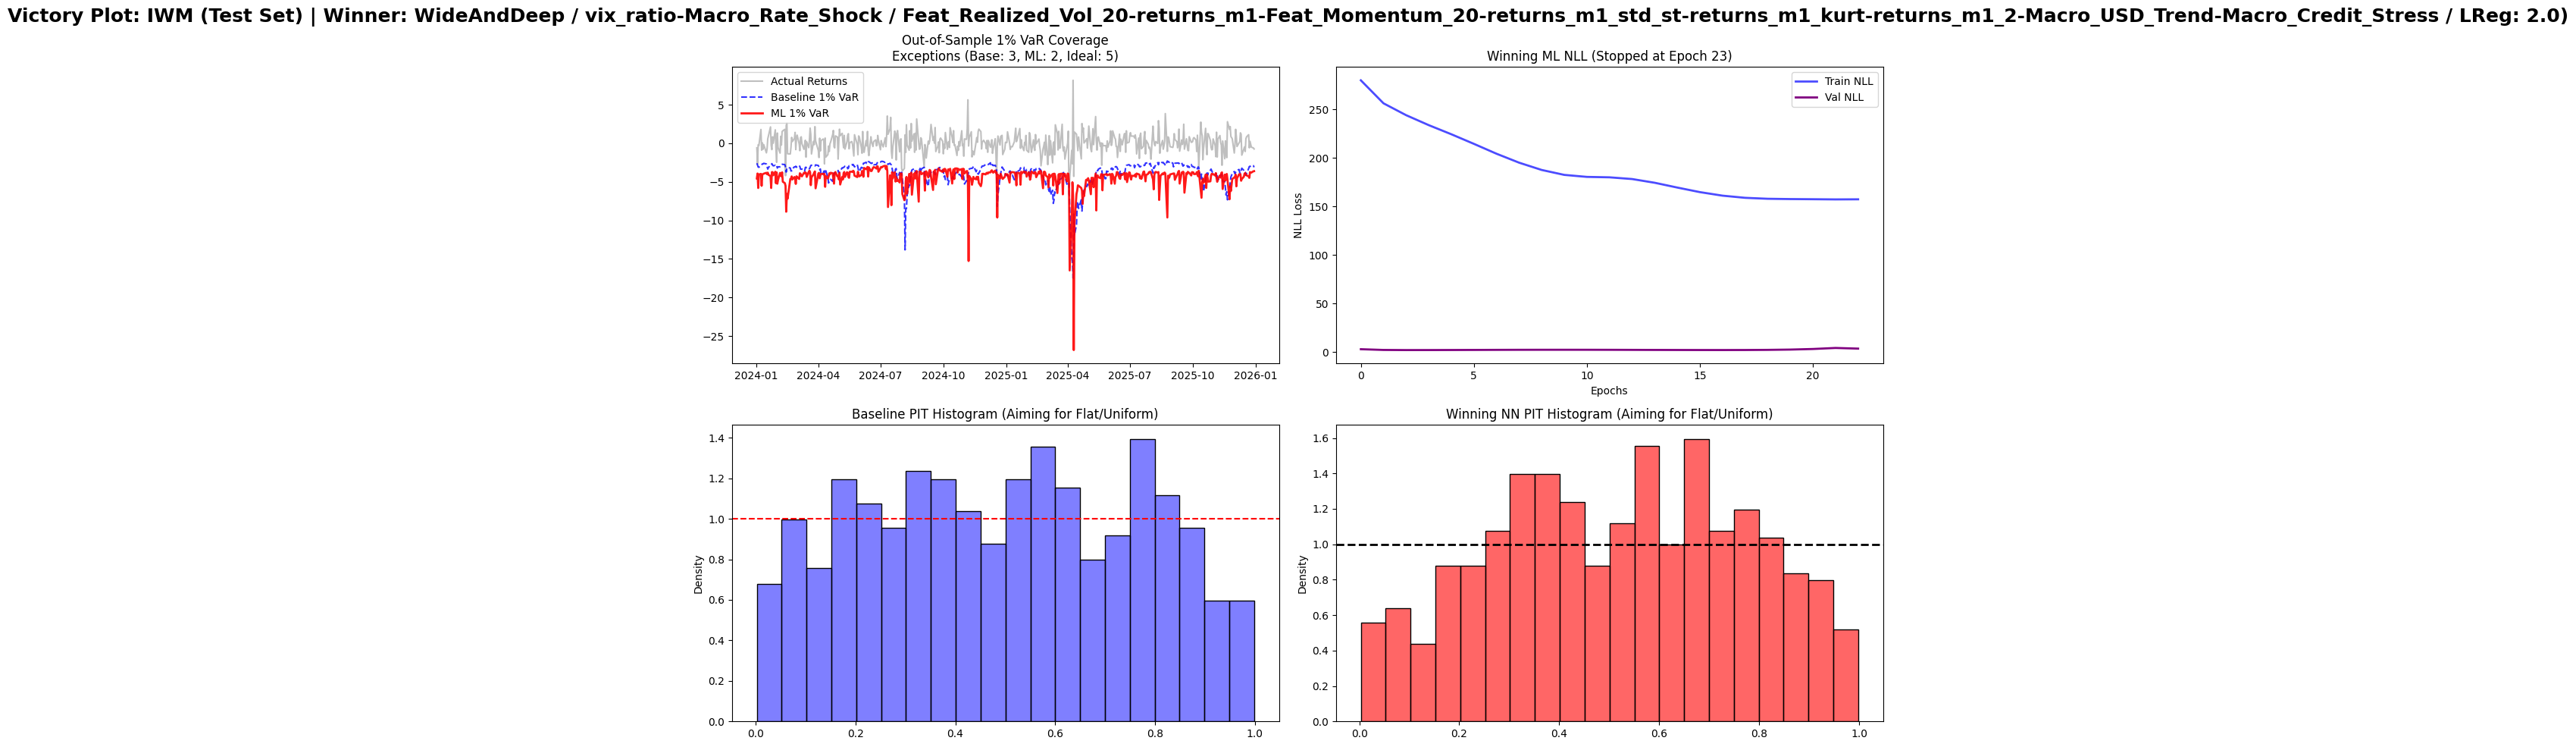

$XLETLT: possibly delisted; no timezone found

1 Failed download:
['XLETLT']: possibly delisted; no timezone found



STATIC SPLIT SHOWDOWN & TUNING: XLETLT
Fetching XLETLT data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


⚠️ Skipping XLETLT: Only 0 days available. Need at least 2500 for robust splits.

STATIC SPLIT SHOWDOWN & TUNING: TSLA
Fetching TSLA data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2765 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 2.7847, ks_stat: 0.0623

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 2.7847 and KS Stat: 0.0623
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SU

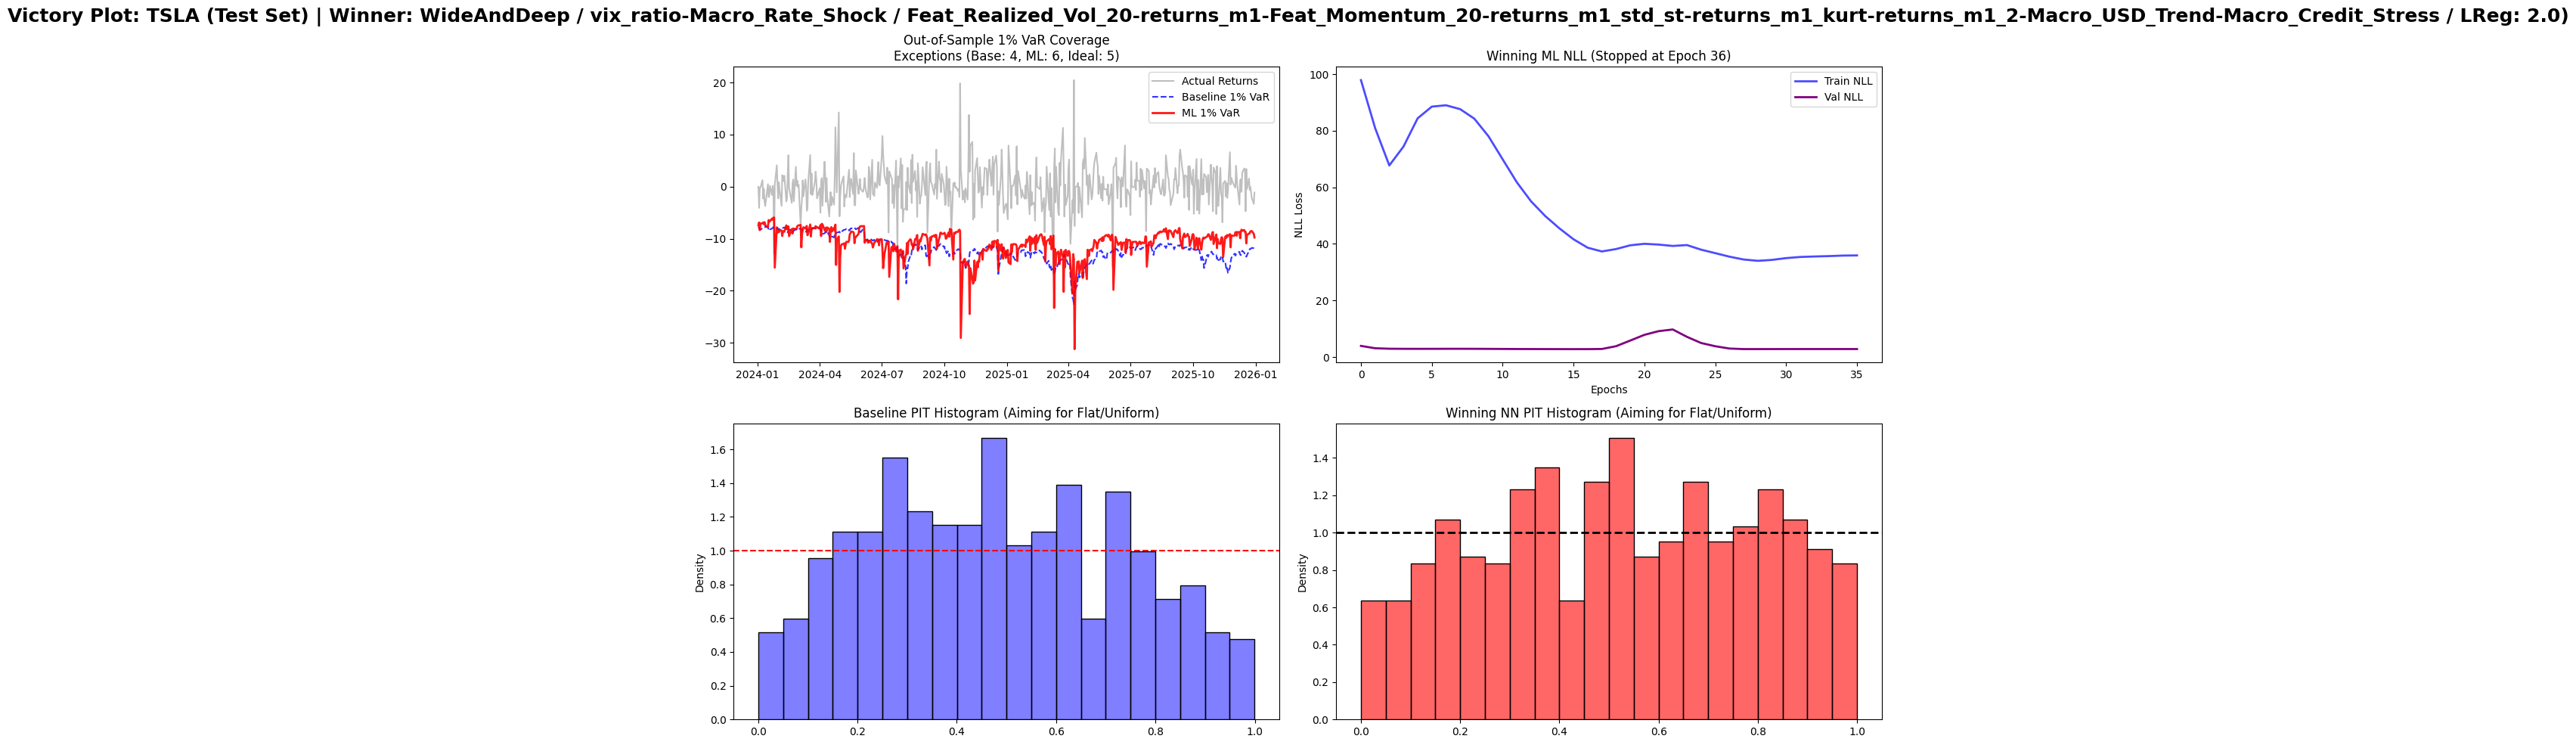


STATIC SPLIT SHOWDOWN & TUNING: ARKK
Fetching ARKK data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 1671 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 2.8183, ks_stat: 0.0989

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 2.8183 and KS Stat: 0.0989
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SUMM

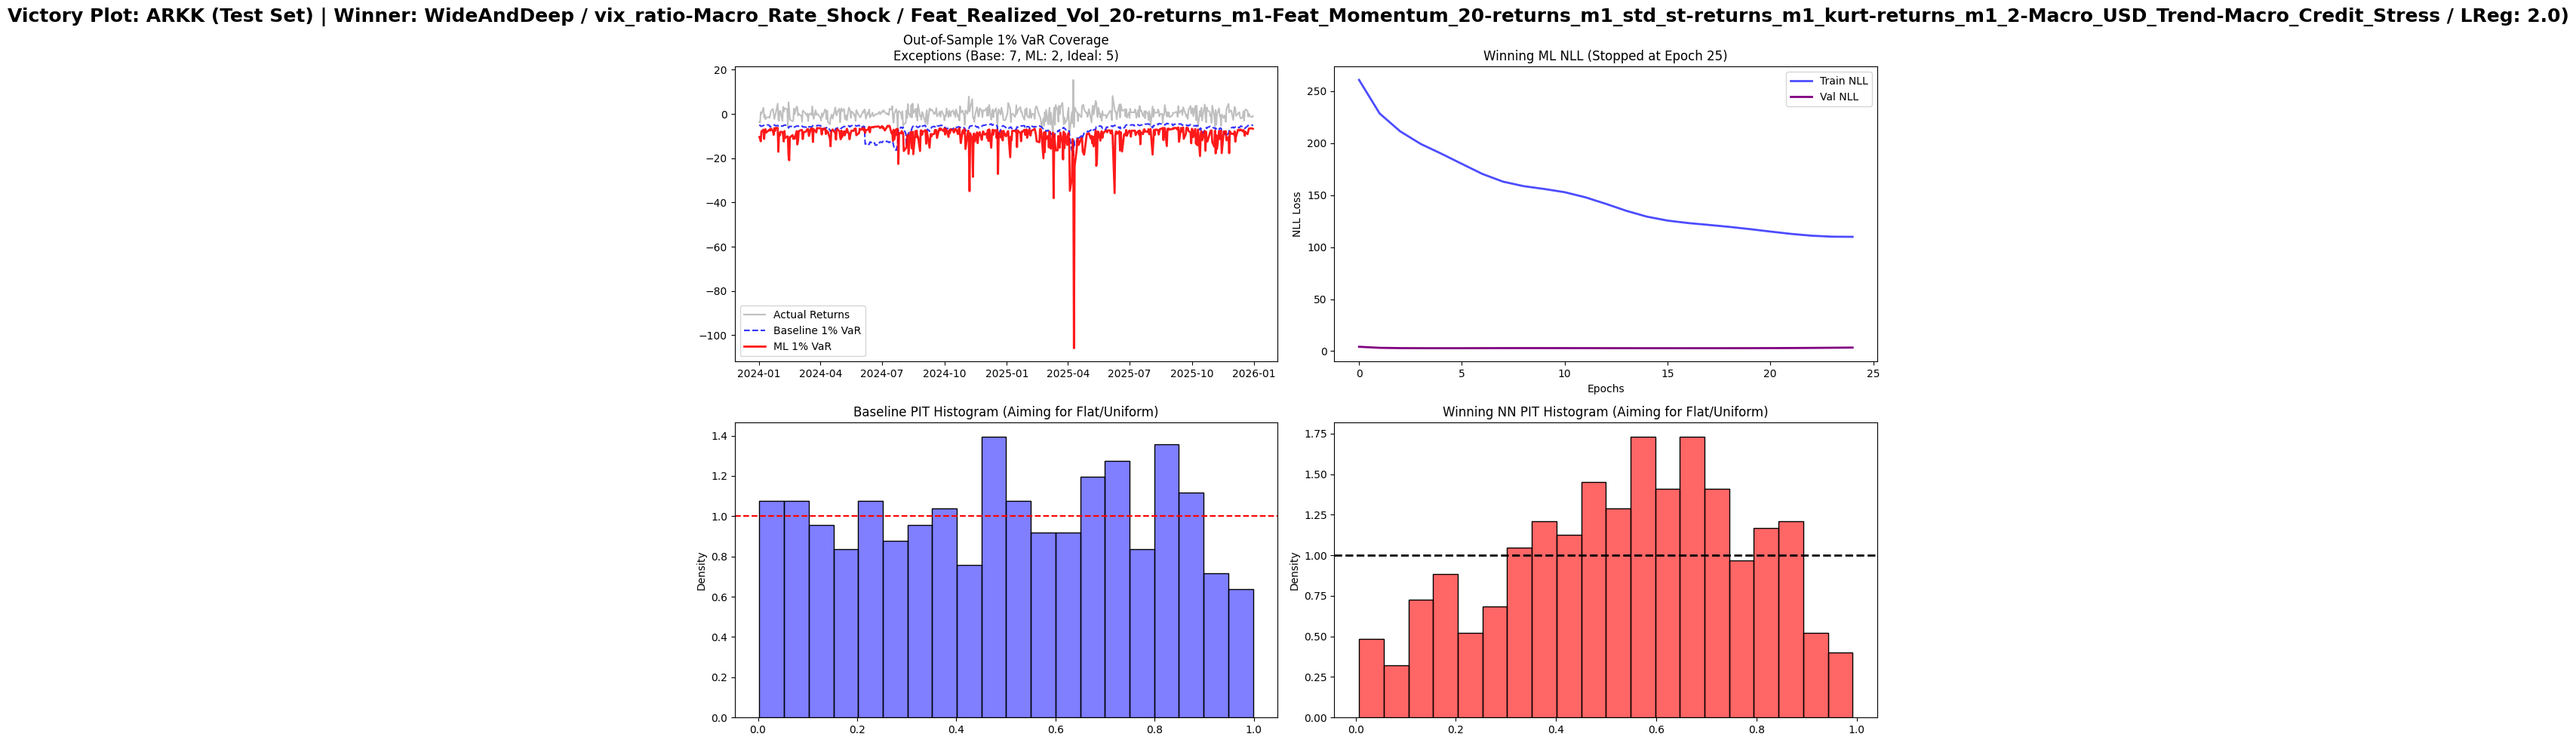


STATIC SPLIT SHOWDOWN & TUNING: USO
Fetching USO data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2806 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 2.3551, ks_stat: 0.0981

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 2.3551 and KS Stat: 0.0981
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SUMM

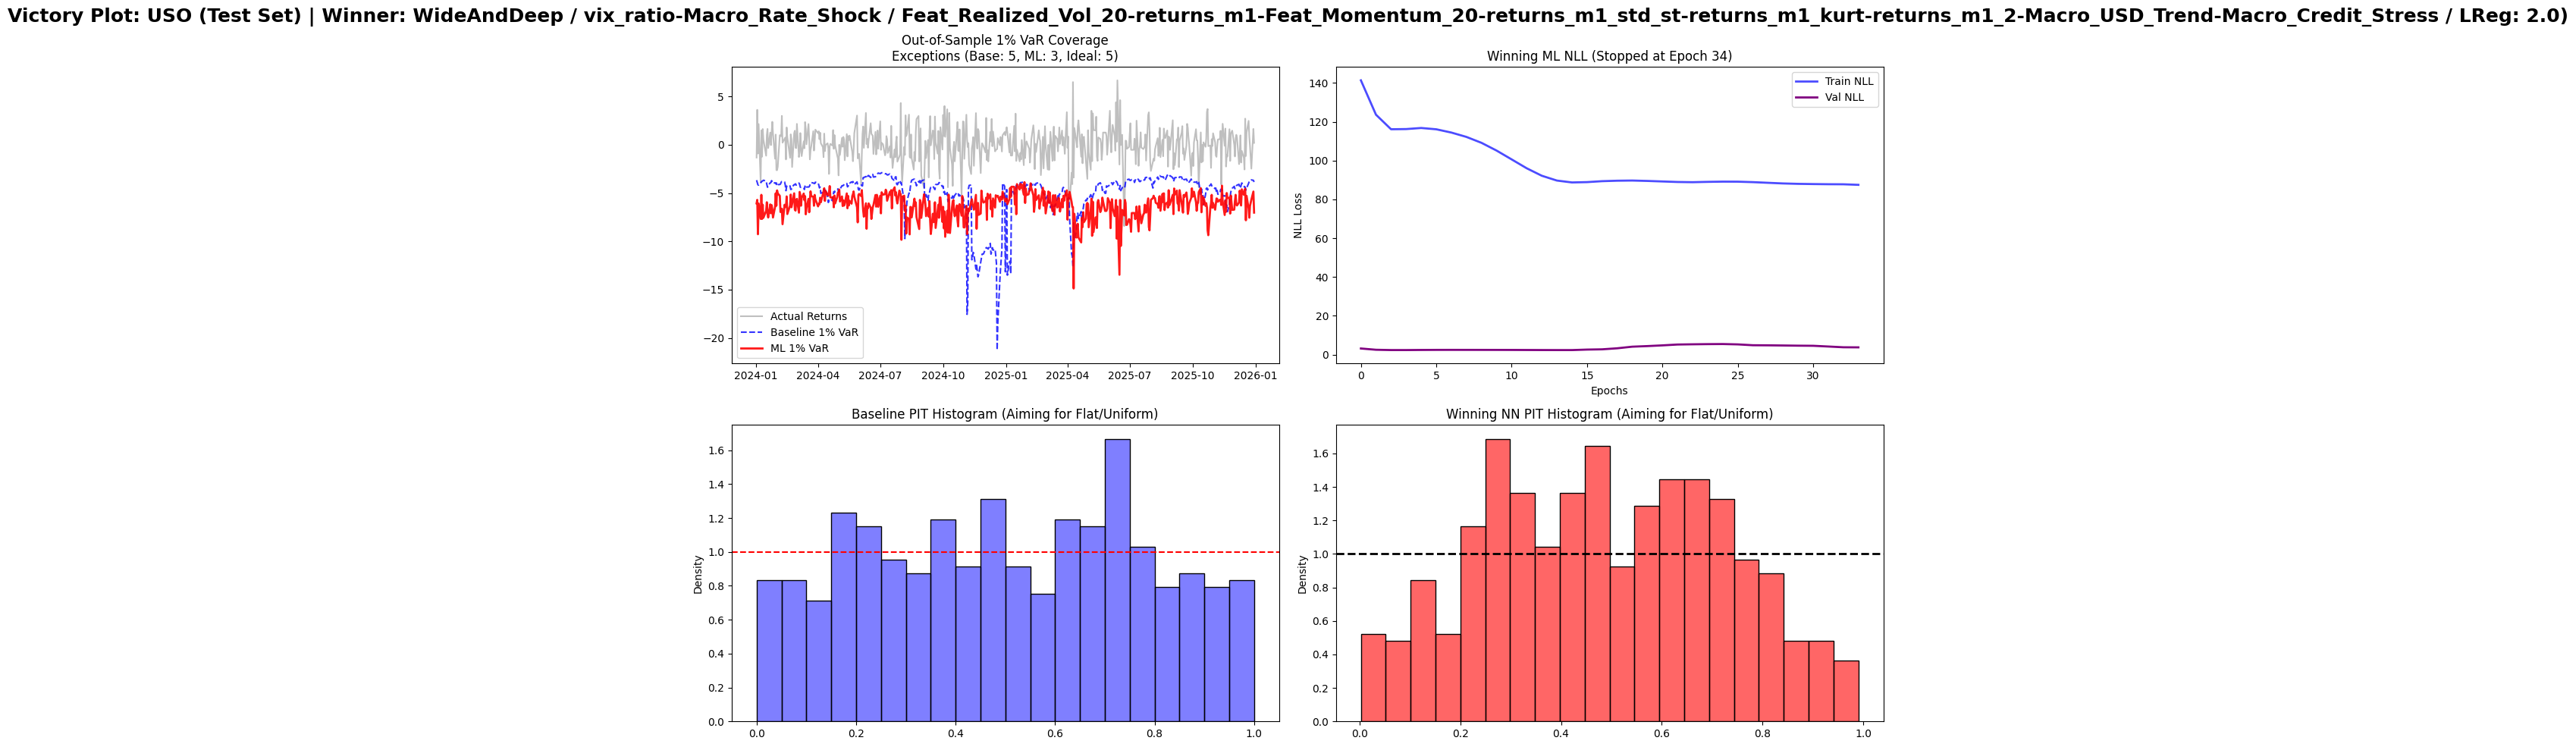


STATIC SPLIT SHOWDOWN & TUNING: XLF
Fetching XLF data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2806 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 1.7053, ks_stat: 0.0701

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 1.7053 and KS Stat: 0.0701
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SU

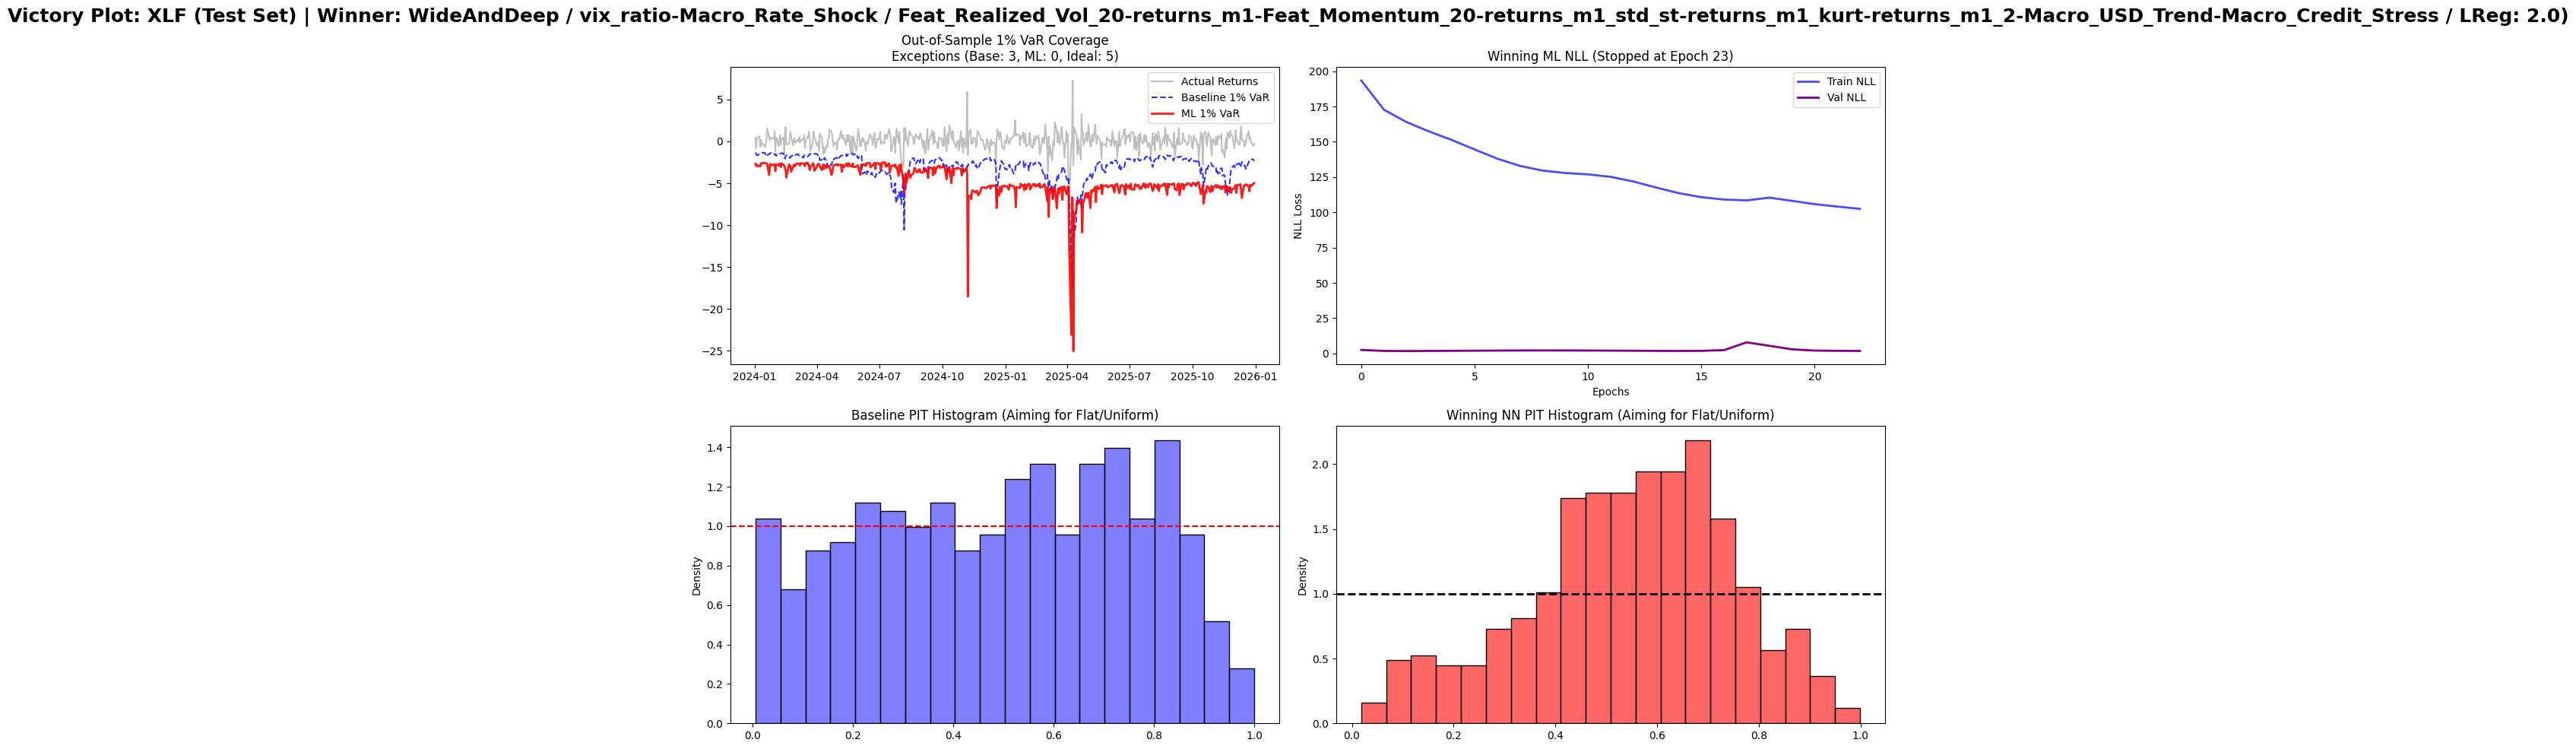


STATIC SPLIT SHOWDOWN & TUNING: EEM
Fetching EEM data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2806 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 1.7024, ks_stat: 0.0845

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 1.7024 and KS Stat: 0.0845
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SU

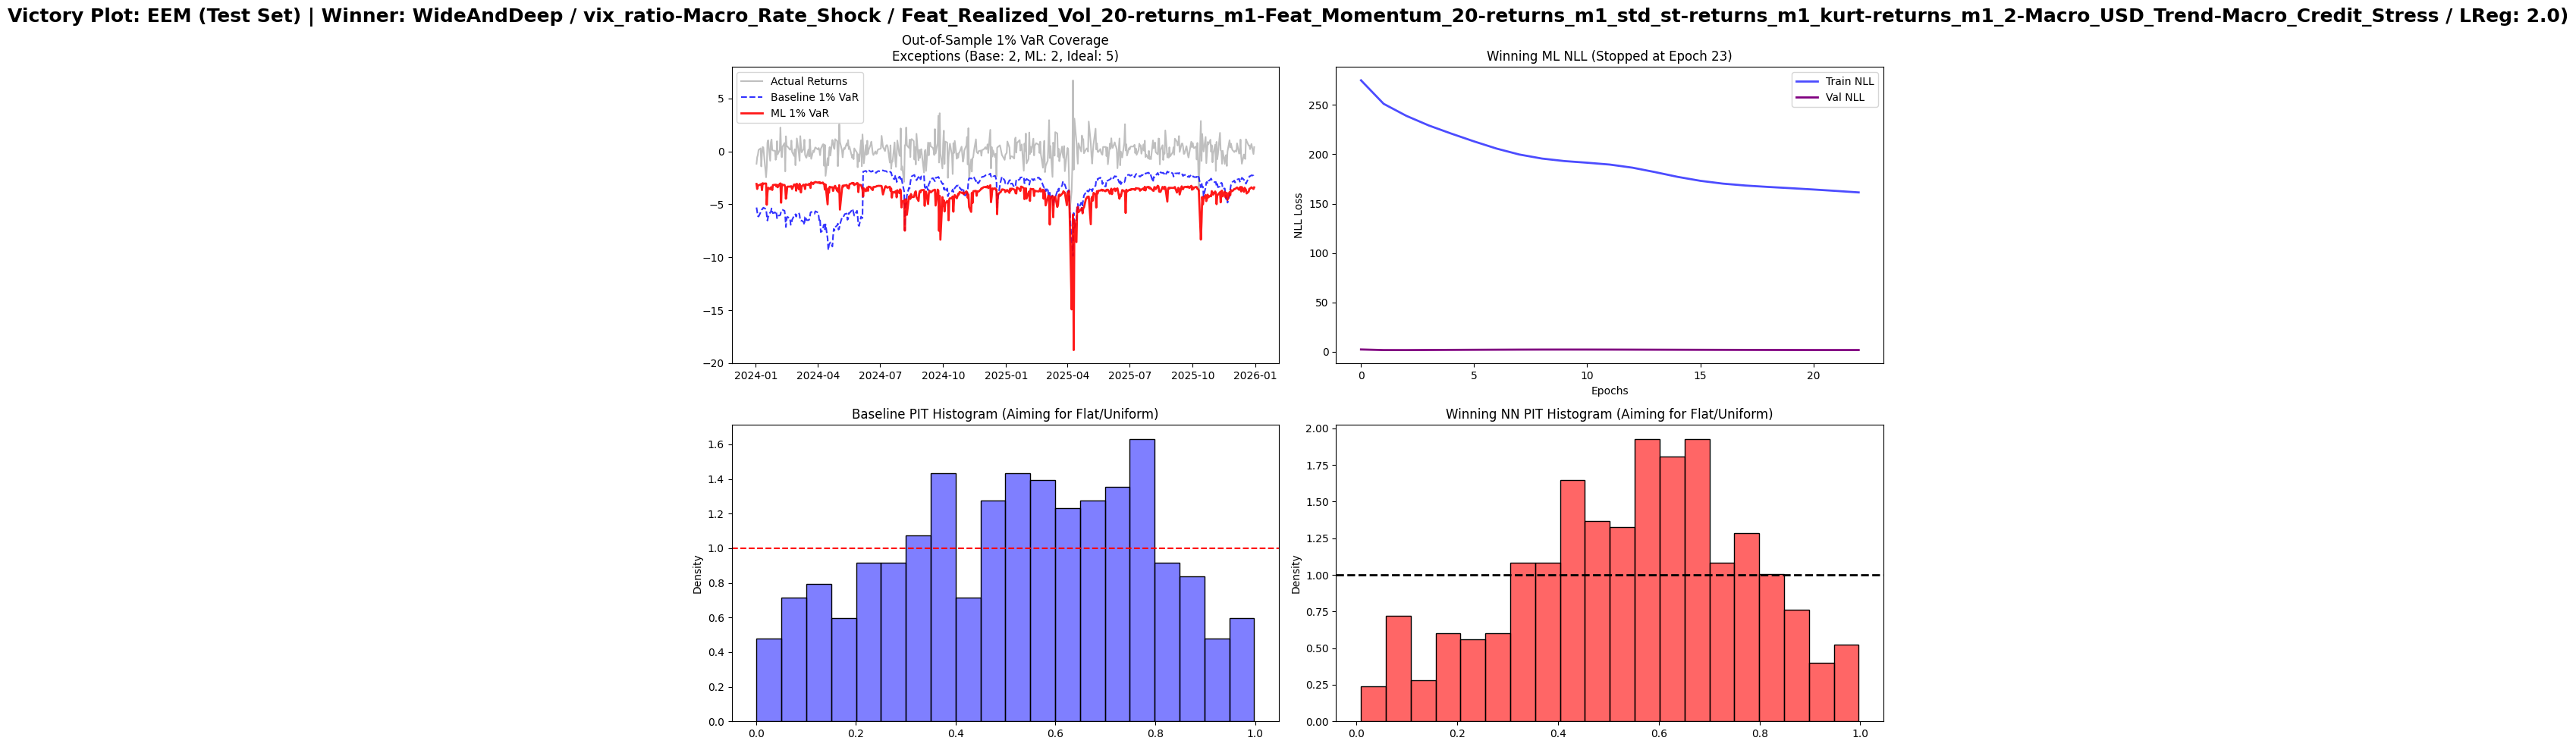


STATIC SPLIT SHOWDOWN & TUNING: ECH
Fetching ECH data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2806 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 2.1427, ks_stat: 0.0544

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 2.1427 and KS Stat: 0.0544
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SUMM

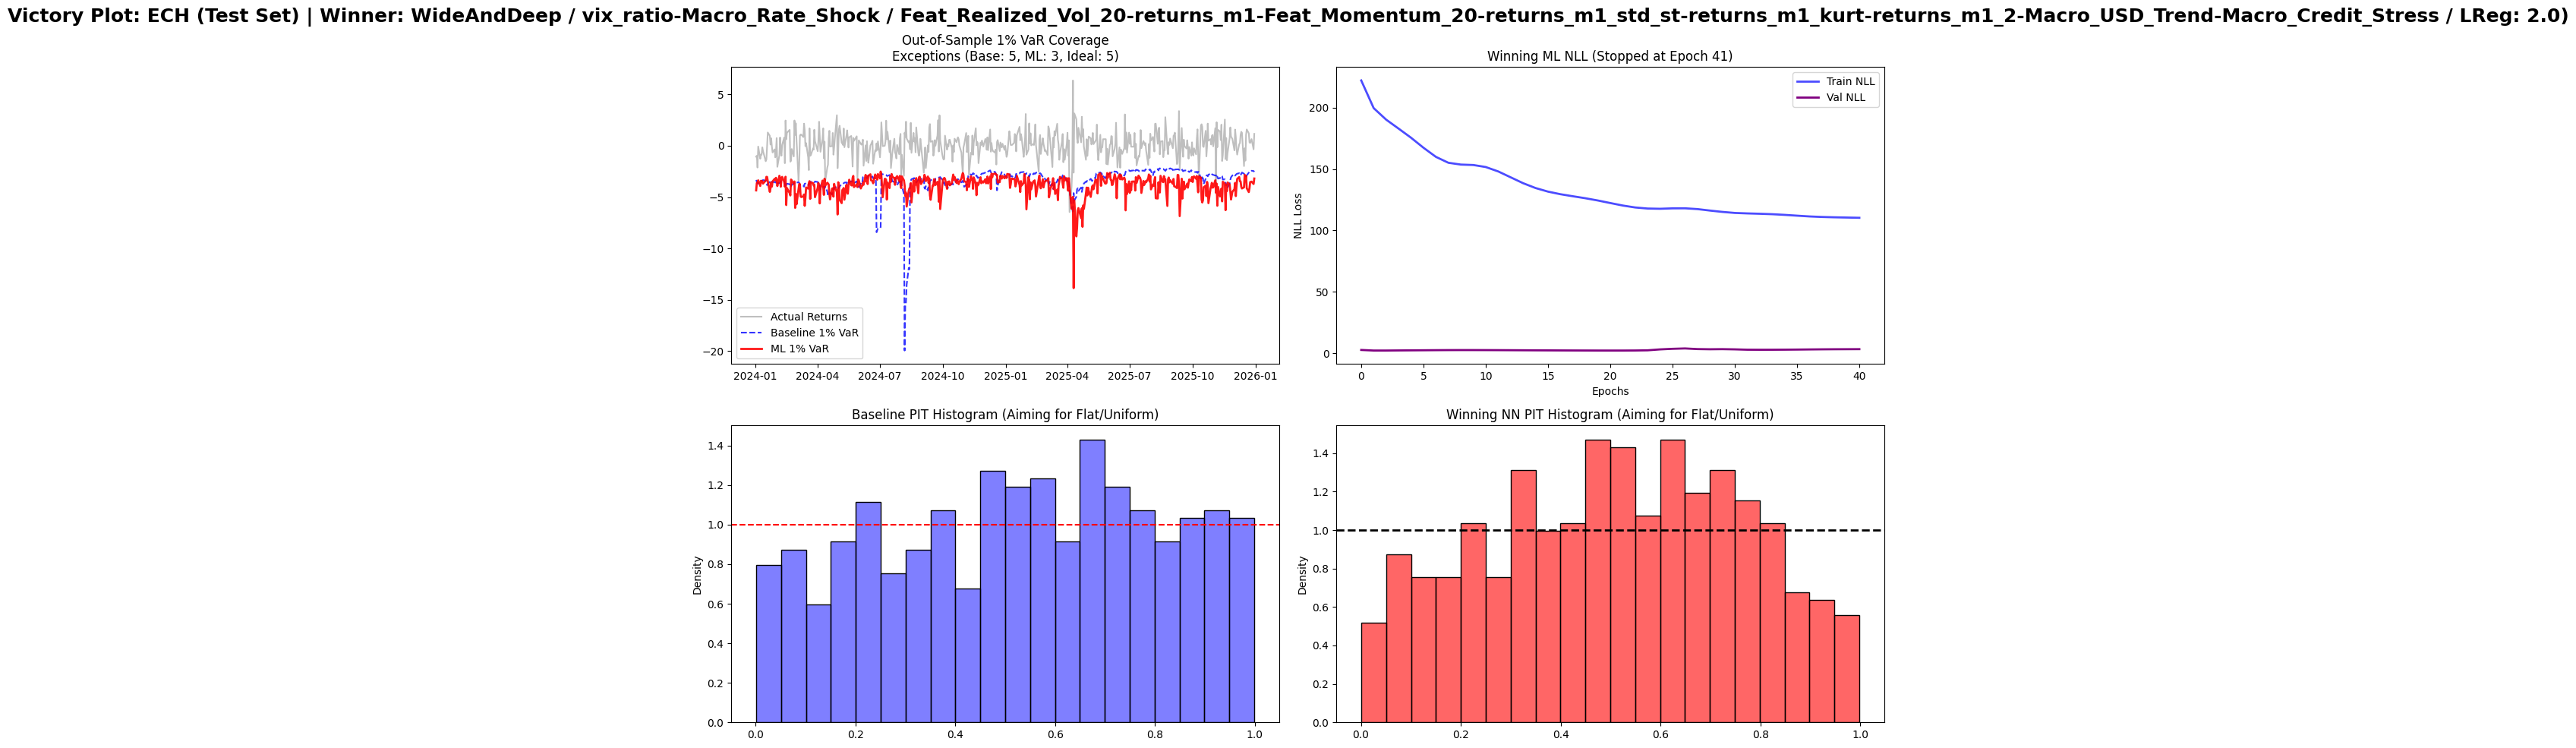


STATIC SPLIT SHOWDOWN & TUNING: NVDA
Fetching NVDA data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2806 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0)

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 2.7616, ks_stat: 0.0778

🏆 WINNING CONFIGURATION: WideAndDeep / vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 2.0) with Val NLL = 2.7616 and KS Stat: 0.0778
calculate metrics baseline

--- INDEPENDENT BLOCK TEST SUMMARY (504-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
calculate metrics Neural-Network

--- INDEPENDENT BLOCK TEST SU

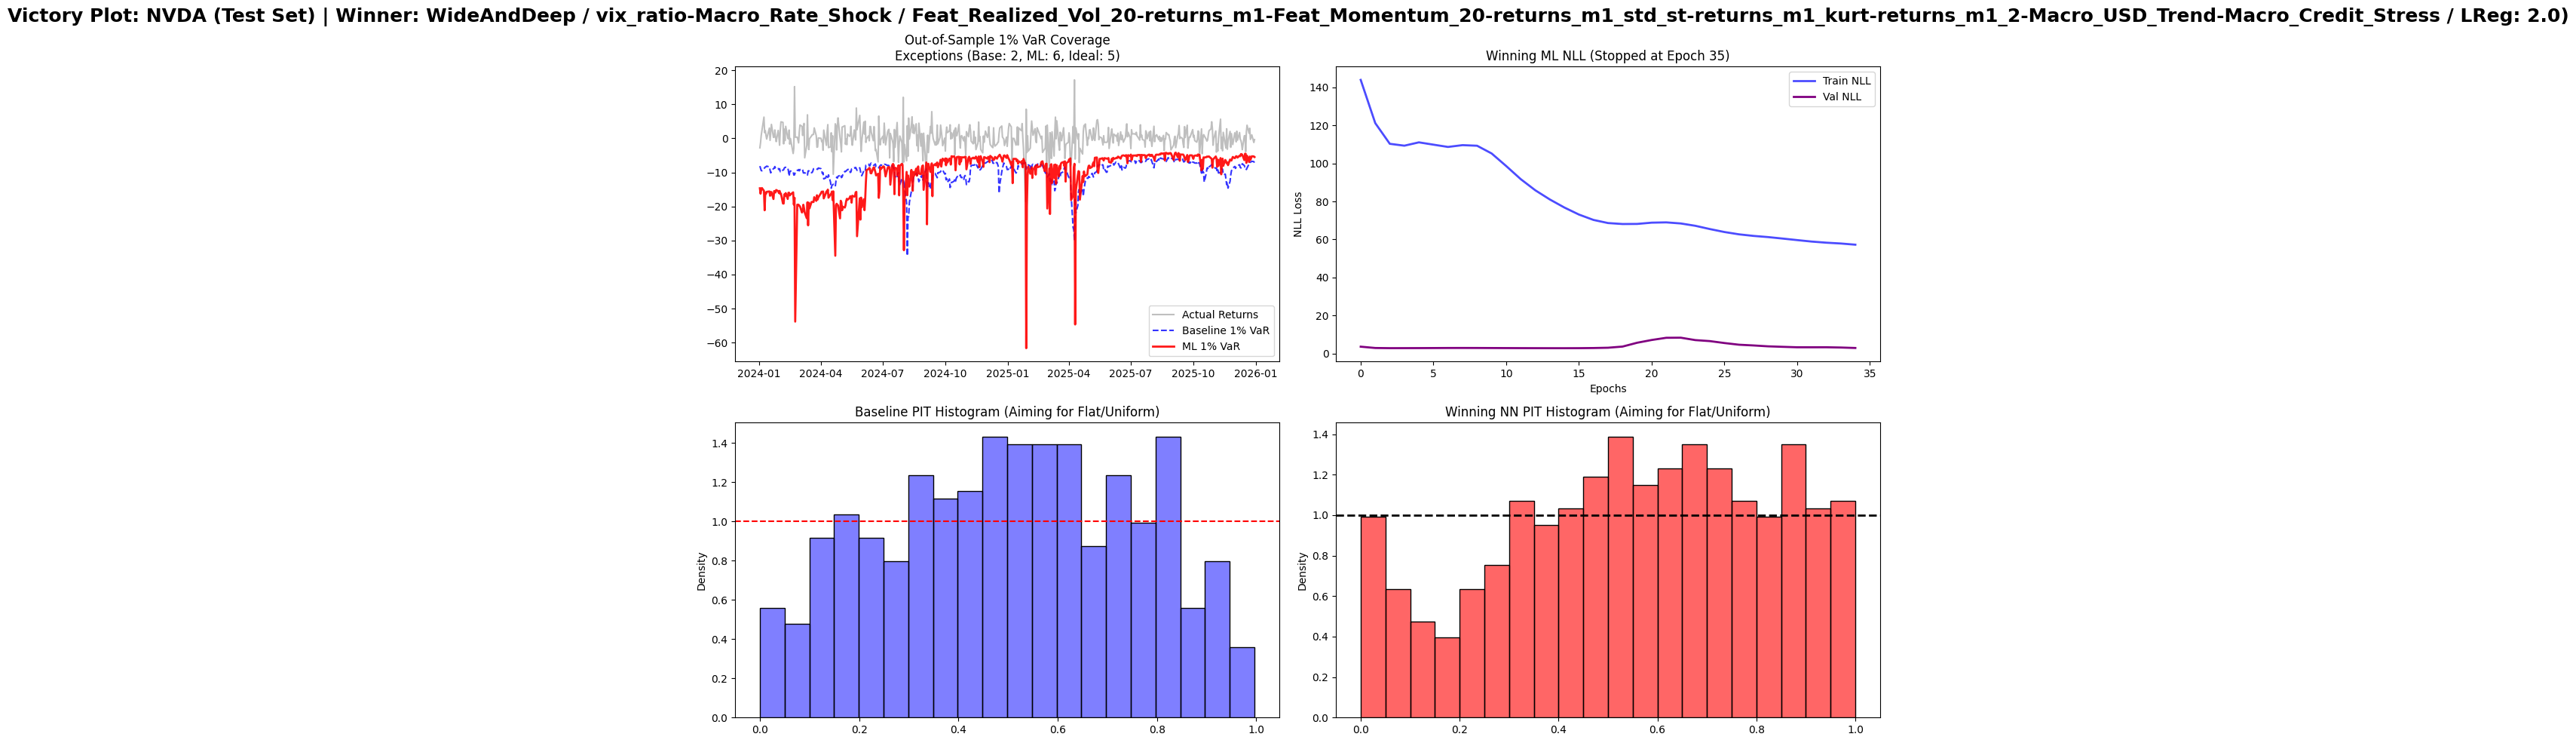

In [73]:
table_results = []

for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"STATIC SPLIT SHOWDOWN & TUNING: {ticker}")
    print(f"{'='*60}")
    
    # 1. Fetch Data
    df_features = read_data_features(ticker, start_date, end_date)
    
    if len(df_features) < MIN_DATA_ROWS:
        print(f"⚠️ Skipping {ticker}: Only {len(df_features)} days available. Need at least {MIN_DATA_ROWS} for robust splits.")
        continue
        
    # 2. Strict Chronological Split
    
    n_val = int(2 * 252)
    n_test = int(2 * 252)
    n_train = len(df_features) - n_test - n_val 

    # Use whatever is left for test, minimum 500
    n_test = len(df_features) - n_train - n_val 
    
    print(f"Data Split -> Train: {n_train} | Val: {n_val} | Test: {n_test}")
    
    y_train = df_features.iloc[:n_train]['returns']
    y_val = df_features.iloc[n_train:n_train+n_val]['returns']
    y_test = df_features.iloc[n_train+n_val:]['returns']

    df_train = df_features.iloc[:n_train]
    df_val = df_features.iloc[n_train:n_train+n_val]
    df_test = df_features.iloc[n_train+n_val:]
    
    # =========================================================
    # NEURAL NETWORK TUNING
    # =========================================================
    print("\n-> Running Neural Network Hyperparameter Grid")
    best_val_loss_overall = np.inf
    # best_val_loss_overall
    best_ks_stat = np.inf
    best_model_class = ""
    best_model_weights = None # Store the actual weights!
    best_config_name = ""

    best_model = None
    best_val_loss_history = []
    best_train_loss_history = []
    
    m_class = 'WideAndDeep'
    # lr = 0.015
    lr = 0.05

    # =========================================================
    # BASELINE MODEL
    # =========================================================
    # print("\n-> Running Baseline (VIX-Scaled Student-T)")
    # Extract Arrays for Baseline
    data_train = extract_array(df_train, y_train)
    data_val = extract_array(df_val, y_val)
    data_test = extract_array(df_test, y_test)

    optimal_beta = run_baseline(data_train, last_optimal_beta=0.5, cold_start=True)
    baseline_results = backtesting_baseline(data_test, optimal_beta)

    baseline_prior_v = backtesting_baseline(data_val, optimal_beta)
    # print(f"len(baseline_prior[mu]) {len(baseline_prior['mu'])}")
    prior_data_v = {'mu': baseline_prior_v['mu'][20:], 'sigma': baseline_prior_v['sigma'][20:], 'nu': baseline_prior_v['nu'][20:]}

    baseline_prior_train = backtesting_baseline(data_train, optimal_beta)
    # print(f"len(baseline_prior[mu]) {len(baseline_prior['mu'])}")
    prior_data_tr = {'mu': baseline_prior_train['mu'][20:], 'sigma': baseline_prior_train['sigma'][20:], 'nu': baseline_prior_train['nu'][20:]}

    for m_class in grid_model_classes:
        for columns_deep in grid_columns_deep:
            for columns_linear in grid_columns_linear:
                for lambda_reg in grid_lambda_regs:
                
                    config_name = f"{m_class} / {'-'.join(columns_deep)} / {'-'.join(columns_linear)} / LReg: {lambda_reg})"
                print(f"   [Grid] Testing: {config_name}")

                # Extract NN Tensors
                # columns_linear.append('vix_ratio_beta')
                # df_train['vix_ratio_beta'] = df_train['vix_ratio']** optimal_beta
                # df_val['vix_ratio_beta'] = df_val['vix_ratio']** optimal_beta
                # df_test['vix_ratio_beta'] = df_test['vix_ratio']** optimal_beta
                # X_lin_tr, X_deep_tr, y_tr = extract_df_nn(df_train, columns_linear, columns_deep)
                # X_lin_v, X_deep_v, y_v = extract_df_nn(df_val, columns_linear, columns_deep)
                # X_lin_te, X_deep_te, y_te = extract_df_nn(df_test, columns_linear, columns_deep)
                
                # Determine if CNN sequence formatting is required
                is_cnn = (m_class == 'conv')
                lookback_days = 20 if is_cnn else 0

                if is_cnn:
                    X_lin_tr, X_deep_tr, y_tr = create_cnn_sequences(df_train[columns_linear], df_train[columns_deep], df_train['returns'], lookback_days)
                    X_lin_v, X_deep_v, y_v = create_cnn_sequences(df_val[columns_linear], df_val[columns_deep], df_val['returns'], lookback_days)
                    prior_data_tr = {'mu': baseline_prior_train['mu'][lookback_days:], 'sigma': baseline_prior_train['sigma'][lookback_days:], 'nu': baseline_prior_train['nu'][lookback_days:]}
                    prior_data_v = {'mu': baseline_prior_v['mu'][lookback_days:], 'sigma': baseline_prior_v['sigma'][lookback_days:], 'nu': baseline_prior_v['nu'][lookback_days:]}
                else:
                    X_lin_tr, X_deep_tr, y_tr = extract_df_nn(df_train, columns_linear, columns_deep)
                    X_lin_v, X_deep_v, y_v = extract_df_nn(df_val, columns_linear, columns_deep)
                    prior_data_tr = {'mu': baseline_prior_train['mu'], 'sigma': baseline_prior_train['sigma'], 'nu': baseline_prior_train['nu']}
                    prior_data_v = {'mu': baseline_prior_v['mu'], 'sigma': baseline_prior_v['sigma'], 'nu': baseline_prior_v['nu']}

                # data_test = extract_array(df_test, y_te)
                # baseline_results = backtesting_baseline(data_test, optimal_beta)
                # print("\n-> Running Neural Networks")
                # model_class_to_use = 'conv'
                model_class_to_use = m_class

                train_step, val_step, model = initializate_nn_model(columns_linear, model_class_to_use, lr, columns_deep=columns_deep, lambda_reg=lambda_reg)
                
                train_loss_history, val_loss_history = run_neural_networks(
                    X_lin_tr, X_deep_tr, y_tr,
                    X_lin_v, X_deep_v, y_v,
                    initial_epochs, train_step, val_step, model, prior_data_train=prior_data_tr, prior_data_v=prior_data_v, verbose=False
                )

                # Evaluate Winning Model on Validation Set
                nn_val_results = backtesting_neural_networks(
                    tf.convert_to_tensor(X_lin_v.to_numpy() if hasattr(X_lin_v, 'to_numpy') else X_lin_v, dtype=tf.float32), 
                    tf.convert_to_tensor(X_deep_v.to_numpy() if hasattr(X_deep_v, 'to_numpy') else X_deep_v, dtype=tf.float32) if X_deep_v is not None else None, 
                    tf.convert_to_tensor(y_v.to_numpy() if hasattr(y_v, 'to_numpy') else y_v, dtype=tf.float32), 
                    model
                )
                # nn_val_results = backtesting_neural_networks(
                #     tf.convert_to_tensor(X_lin_v.to_numpy(), dtype=tf.float32), 
                #     tf.convert_to_tensor(X_deep_v.to_numpy(), dtype=tf.float32) if X_deep_v is not None else None, 
                #     tf.convert_to_tensor(y_v.to_numpy(), dtype=tf.float32), 
                #     model
                # )
                
                # Calculate Validation KS Stat
                ks_stat = block_ks_test(pd.DataFrame(nn_val_results['pit_values']), block_size=len(pd.DataFrame(nn_val_results['pit_values'])), alpha=0.05)['KS_Stat'].values[0]
                ks_stat = ks_stat[0]
                min_val = min(val_loss_history)

                
                print(f"          Achieved Best Val NLL: {min_val:.4f}, ks_stat: {ks_stat:.4f}")
                # print(block_ks_test(pd.DataFrame(nn_results['pit_values']), block_size=len(pd.DataFrame(nn_results['pit_values'])), alpha=0.05))

                # if min_val < best_val_loss_overall:

                # if (ks_stat < best_ks_stat) and (min_val < best_val_loss_overall):
                if (min_val < best_val_loss_overall):

                # if (ks_stat < best_ks_stat):
                    best_ks_stat = ks_stat
                    best_val_loss_overall = min_val
                    
                    # SAVE THE WEIGHTS, not the model reference
                    best_model_class = m_class
                    best_model_weights = model.get_weights()

                    # best_model = model
                    best_config_name = config_name
                    best_val_loss_history = val_loss_history
                    best_train_loss_history = train_loss_history
                    best_columns_deep = columns_deep
                    best_columns_linear = columns_linear
                    
    print(f"\n🏆 WINNING CONFIGURATION: {best_config_name} with Val NLL = {best_val_loss_overall:.4f} and KS Stat: {best_ks_stat:.4f}")
    
    # =========================================================
    # PRODUCTION-GRADE WALK-FORWARD VALIDATION ON TEST PERIOD
    # =========================================================
    print(f"\n-> Running Expanding Window Walk-Forward Validation ({best_model_class})")
    
    # Window definitions
    INITIAL_TRAIN_DAYS = 1250
    VAL_DAYS = 250
    STEP_SIZE = 21

    lookback_best = 20 if (best_model_class == 'conv') else 0

    # Prep sequenced features on full dataset to avoid lookback-related data loss at each step
    if best_model_class == 'conv':
        X_lin_seq, X_deep_seq, y_seq = create_cnn_sequences(
            df_features[best_columns_linear], df_features[best_columns_deep], df_features['returns'], lookback_best
        )
    else:
        X_lin_seq = df_features[best_columns_linear].to_numpy()
        X_deep_seq = df_features[best_columns_deep].to_numpy() if best_columns_deep else None
        y_seq = df_features['returns'].to_numpy()

    # Step list initializations
    all_dates = []
    actual_y = []
    baseline_mu = []
    baseline_sigma = []
    baseline_nu = []
    baseline_pit = []

    nn_mu = []
    nn_sigma = []
    nn_nu = []
    nn_pit = []

    P_start = INITIAL_TRAIN_DAYS + VAL_DAYS
    P = P_start
    step_count = 1
    total_steps = (len(df_features) - P_start) // STEP_SIZE

    # Re-initialize NN cleanly ONCE before entering the walk-forward loop (loads best weights)
    best_lambda_reg = float(best_config_name.split()[-1].strip(')'))
    train_step, val_step, best_model = initializate_nn_model(
        best_columns_linear, best_model_class, lr, columns_deep=best_columns_deep, lambda_reg=best_lambda_reg
    )
    best_model.set_weights(best_model_weights)

    # Use fewer epochs (fine-tuning) for the incremental steps during walk-forward
    epochs_per_step = 10

    while P + STEP_SIZE <= len(df_features):
        test_end = P + STEP_SIZE
        test_dates = df_features.index[P : test_end]
        print(f"   [Walk-Forward] Step {step_count}/{total_steps}: Training up to {df_features.index[P-1].strftime('%Y-%m-%d')}, Predicting next {STEP_SIZE} days...")
        
        # 1. Baseline Model slice (2D)
        df_train_step = df_features.iloc[0 : P - VAL_DAYS]
        df_val_step = df_features.iloc[P - VAL_DAYS : P]
        df_test_step = df_features.iloc[P : test_end]
        
        data_train_step = extract_array(df_train_step, df_train_step['returns'])
        data_val_step = extract_array(df_val_step, df_val_step['returns'])
        data_test_step = extract_array(df_test_step, df_test_step['returns'])
        
        # Fit baseline
        optimal_beta = run_baseline(data_train_step, last_optimal_beta=0.5, cold_start=True)
        baseline_results_step = backtesting_baseline(data_test_step, optimal_beta)
        
        # Compute baseline priors for NN validation & training
        baseline_prior_v = backtesting_baseline(data_val_step, optimal_beta)
        baseline_prior_train = backtesting_baseline(data_train_step, optimal_beta)
        
        # Align priors with NN lookback
        prior_data_v = {
            'mu': baseline_prior_v['mu'],
            'sigma': baseline_prior_v['sigma'],
            'nu': baseline_prior_v['nu']
        }
        prior_data_tr = {
            'mu': baseline_prior_train['mu'][lookback_best:],
            'sigma': baseline_prior_train['sigma'][lookback_best:],
            'nu': baseline_prior_train['nu'][lookback_best:]
        }
        
        # 2. Slice sequenced features for NN
        X_lin_tr = X_lin_seq[0 : P - VAL_DAYS - lookback_best]
        X_deep_tr = X_deep_seq[0 : P - VAL_DAYS - lookback_best] if X_deep_seq is not None else None
        y_tr = y_seq[0 : P - VAL_DAYS - lookback_best]
        
        X_lin_v = X_lin_seq[P - VAL_DAYS - lookback_best : P - lookback_best]
        X_deep_v = X_deep_seq[P - VAL_DAYS - lookback_best : P - lookback_best] if X_deep_seq is not None else None
        y_v = y_seq[P - VAL_DAYS - lookback_best : P - lookback_best]
        
        X_lin_te = X_lin_seq[P - lookback_best : test_end - lookback_best]
        X_deep_te = X_deep_seq[P - lookback_best : test_end - lookback_best] if X_deep_seq is not None else None
        y_te = y_seq[P - lookback_best : test_end - lookback_best]
        
        # Train NN incrementally (warm start)
        train_loss_history, val_loss_history = run_neural_networks(
            X_lin_tr, X_deep_tr, y_tr,
            X_lin_v, X_deep_v, y_v,
            epochs_per_step, train_step, val_step, best_model,
            prior_data_train=prior_data_tr, prior_data_v=prior_data_v, verbose=False
        )
        
        # Predict test block
        nn_results_step = backtesting_neural_networks(
            tf.convert_to_tensor(X_lin_te, dtype=tf.float32),
            tf.convert_to_tensor(X_deep_te, dtype=tf.float32) if X_deep_te is not None else None,
            tf.convert_to_tensor(y_te, dtype=tf.float32),
            best_model
        )
        
        # Append step results
        all_dates.append(test_dates)
        actual_y.append(y_te)
        
        baseline_mu.append(baseline_results_step['mu'])
        baseline_sigma.append(baseline_results_step['sigma'])
        baseline_nu.append(baseline_results_step['nu'])
        baseline_pit.append(baseline_results_step['pit_values'])
        
        nn_mu.append(nn_results_step['mu'])
        nn_sigma.append(nn_results_step['sigma'])
        nn_nu.append(nn_results_step['nu'])
        nn_pit.append(nn_results_step['pit_values'])
        
        P += STEP_SIZE
        step_count += 1

    # Concatenate OOS periods
    OOS_dates = pd.Index(np.concatenate(all_dates))
    actual_returns = np.concatenate(actual_y)

    baseline_results_aligned = {
        'mu': np.concatenate(baseline_mu),
        'sigma': np.concatenate(baseline_sigma),
        'nu': np.concatenate(baseline_nu),
        'pit_values': np.concatenate(baseline_pit)
    }

    nn_results = {
        'mu': np.concatenate(nn_mu),
        'sigma': np.concatenate(nn_sigma),
        'nu': np.concatenate(nn_nu),
        'pit_values': np.concatenate(nn_pit)
    }

    y_te_aligned = pd.Series(actual_returns, index=OOS_dates)
    actual_returns = y_te_aligned.values

        # Re-extract the winning test features!
    # X_lin_te_winning, X_deep_te_winning, _ = extract_df_nn(df_test, best_columns_linear, best_columns_deep)

    # # Evaluate Winning Model on Test Set
    # nn_results = backtesting_neural_networks(
    #     tf.convert_to_tensor(X_lin_te_winning.to_numpy(), dtype=tf.float32), 
    #     tf.convert_to_tensor(X_deep_te_winning.to_numpy(), dtype=tf.float32) if X_deep_te_winning is not None else None, 
    #     tf.convert_to_tensor(y_te.to_numpy(), dtype=tf.float32), 
    #     best_model
    # )

    # # Evaluate Winning Model on Test Set
    # nn_results = backtesting_neural_networks(
    #     tf.convert_to_tensor(X_lin_te.to_numpy(), dtype=tf.float32), 
    #     tf.convert_to_tensor(X_deep_te.to_numpy(), dtype=tf.float32) if X_deep_te is not None else None, 
    #     tf.convert_to_tensor(y_te.to_numpy(), dtype=tf.float32), 
    #     best_model
    # )
    
    # =========================================================
    # METRICS EVALUATION
    # =========================================================
    # actual_returns = y_te.values
    # actual_returns = y_te

    
    def calculate_metrics(results_dict):
        mu = results_dict['mu']
        sigma = results_dict['sigma']
        nu = results_dict['nu']
        pit = results_dict['pit_values']
        df_ks_pit = block_ks_test(pd.DataFrame(pit), block_size=len(pit), alpha=0.05)
        # ks_stat = df_ks['KS_Stat']
        
        pit_accept = df_ks_pit['Status'].values[0]

        # CRPS
        ensembles = generate_montecarlo(mu, sigma, nu, n_samples=1000)
        df_eval = evaluate_forecasts(y_te, ensembles)
        crps = df_eval['CRPS'].mean()
        nll = -df_eval['Log_Likelihood'].sum()
        
        # VaR 99% for Kupiec Test
        var_99 = t.ppf(0.01, df=nu, loc=mu, scale=sigma)
        # print('calculate metrics results')
        # print(len(actual_returns[actual_returns < var_99]), len(actual_returns))
        kupiec = kupiec_pof_test(actual_returns, var_99, confidence_level=0.99)
        # print(kupiec)
        # print('P_Value: ', kupiec['P_Value'])

        return crps, nll, kupiec, var_99, pit, df_ks_pit
    
    # Update calculate_metrics to use y_te_aligned internally
    def calculate_metrics_aligned(results_dict):
        mu = results_dict['mu']
        sigma = results_dict['sigma']
        nu = results_dict['nu']
        pit = results_dict['pit_values']
        df_ks_pit = block_ks_test(pd.DataFrame(pit), block_size=len(pit), alpha=0.05)
        
        pit_accept = df_ks_pit['Status'].values[0]

        # CRPS
        ensembles = generate_montecarlo(mu, sigma, nu, n_samples=1000)
        df_eval = evaluate_forecasts(y_te_aligned, ensembles)
        crps = df_eval['CRPS'].mean()
        nll = -df_eval['Log_Likelihood'].sum()
        
        # VaR 99% for Kupiec Test
        var_99 = t.ppf(0.01, df=nu, loc=mu, scale=sigma)
        kupiec = kupiec_pof_test(actual_returns, var_99, confidence_level=0.99)

        return crps, nll, kupiec, var_99, pit, df_ks_pit

    print('calculate metrics baseline')
    crps_base, nll_base, kupiec_base, var_base, pit_base, pit_ks_base = calculate_metrics_aligned(baseline_results_aligned)
    print('calculate metrics Neural-Network')
    crps_nn, nll_nn, kupiec_nn, var_nn, pit_nn, pit_ks_nn = calculate_metrics_aligned(nn_results)
    
    table_results.append({
        'Ticker': ticker,
        'Winning_NN_Config': best_config_name,
        'NLL_Baseline': nll_base,
        'NLL_ML': nll_nn,
        'CRPS_Baseline': crps_base,
        'CRPS_ML': crps_nn,
        'LR_Statistic_base': float(kupiec_base['LR_Statistic']),
        'LR_Statistic_ML': float(kupiec_nn['LR_Statistic']),
        'PIT_Statistic_base': float(pit_ks_base['KS_Stat'].iloc[0][0]),
        'PIT_Statistic_ML': float(pit_ks_nn['KS_Stat'].iloc[0][0]),

        'Exceptions_Base': f"{kupiec_base['Exceptions']} / {int(kupiec_base['Expected'])}",
        'Exceptions_ML': f"{kupiec_nn['Exceptions']} / {int(kupiec_nn['Expected'])}",
        'Kupiec_Base_Status': kupiec_base['Status'],
        'Kupiec_ML_Status': kupiec_nn['Status'],
        'KS_PIT_Base_Result': pit_ks_base['Status'].iloc[0][0],
        'KS_PIT_ML_Result': pit_ks_nn['Status'].iloc[0][0]
    })
    
    # =========================================================
    # VICTORY PLOTS
    # =========================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Victory Plot: {ticker} (Test Set) | Winner: {best_config_name}", fontsize=18, fontweight='bold')
    
    # Plot 1: 1% VaR Exceedance Coverage
    dates_test = y_te_aligned.index
    axes[0, 0].plot(dates_test, actual_returns, label='Actual Returns', color='gray', alpha=0.5)
    axes[0, 0].plot(dates_test, var_base, label='Baseline 1% VaR', color='blue', alpha=0.8, linestyle='--')
    axes[0, 0].plot(dates_test, var_nn, label='ML 1% VaR', color='red', alpha=0.9, linewidth=2)
    axes[0, 0].set_title(f"Out-of-Sample 1% VaR Coverage\nExceptions (Base: {kupiec_base['Exceptions']}, ML: {kupiec_nn['Exceptions']}, Ideal: {int(kupiec_nn['Expected'])})")
    axes[0, 0].legend()
    
    # Plot 2: Validation Loss Curve (Early Stopping)
    axes[0, 1].plot(best_train_loss_history, label='Train NLL', color='blue', alpha=0.7, linewidth=2)
    axes[0, 1].plot(best_val_loss_history, label='Val NLL', color='purple', linewidth=2)
    axes[0, 1].set_title(f"Winning ML NLL (Stopped at Epoch {len(best_val_loss_history)})")
    axes[0, 1].set_xlabel("Epochs")
    axes[0, 1].set_ylabel("NLL Loss")
    axes[0, 1].legend()
    
    # Plot 3: Baseline PIT Histogram
    sns.histplot(pit_base, bins=20, color='blue', alpha=0.5, stat='density', ax=axes[1, 0])
    axes[1, 0].axhline(1.0, color='red', linestyle='--')
    axes[1, 0].set_title("Baseline PIT Histogram (Aiming for Flat/Uniform)")
    
    # Plot 4: ML PIT Histogram
    sns.histplot(pit_nn, bins=20, color='red', alpha=0.6, stat='density', ax=axes[1, 1])
    axes[1, 1].axhline(1.0, color='black', linestyle='--', linewidth=2)
    axes[1, 1].set_title("Winning NN PIT Histogram (Aiming for Flat/Uniform)")
    
    plt.tight_layout()
    plt.savefig('../outputs/showdown_fig_01.pdf', dpi=300, bbox_inches='tight')
    plt.show()


## 2. Quantitative Summary & Export

In [74]:
# import os
# df_res = pd.DataFrame(table_results)
# # df_res 
# df_res['Winner'] = 'Tie'
# df_res.loc[(df_res.PIT_Statistic_base > df_res.PIT_Statistic_base) & (df_res.LR_Statistic_base > df_res.LR_Statistic_ML), 'Winner'] = 'Baseline'
# df_res.loc[(df_res.PIT_Statistic_base < df_res.PIT_Statistic_base) & (df_res.LR_Statistic_base < df_res.LR_Statistic_ML), 'Winner'] = 'ML'
# df_res


In [6]:
import os
df_res = pd.DataFrame(table_results)
if len(df_res) > 0:
    df_res.set_index('Ticker', inplace=True)
    df_res['NLL_Winner'] = np.where(df_res['NLL_ML'] < df_res['NLL_Baseline'], 'ML', 'Baseline')
    df_res['CRPS_Winner'] = np.where(df_res['CRPS_ML'] < df_res['CRPS_Baseline'], 'ML', 'Baseline')
    df_res['Winner'] = 'Tie'
    df_res.loc[(df_res.PIT_Statistic_base < df_res.PIT_Statistic_ML) & (df_res.LR_Statistic_base < df_res.LR_Statistic_ML), 'Winner'] = 'Baseline'
    df_res.loc[(df_res.PIT_Statistic_base > df_res.PIT_Statistic_ML) & (df_res.LR_Statistic_base > df_res.LR_Statistic_ML), 'Winner'] = 'ML'
    display(df_res)
    
    output_dir = '../outputs'
    os.makedirs(output_dir, exist_ok=True)
    
    # Re-order and export
    export_cols = ['Winning_NN_Config', 'NLL_Baseline', 'NLL_ML', 'NLL_Winner', 
                   'CRPS_Baseline', 'CRPS_ML', 'CRPS_Winner', 
                   'Exceptions_Base', 'Exceptions_ML', 'Kupiec_Base_Status', 'Kupiec_ML_Status']
    
    df_export = df_res[export_cols]
    df_export.to_csv(f'{output_dir}/showdown_results_static.csv')
    df_export.to_json(f'{output_dir}/showdown_results_static.json', orient='index')
    
    print(f'Results successfully saved to {output_dir}')
else:
    print("No valid results to display.")


,Winning_NN_Config,NLL_Baseline,NLL_ML,CRPS_Baseline,CRPS_ML,LR_Statistic_base,LR_Statistic_ML,PIT_Statistic_base,PIT_Statistic_ML,Exceptions_Base,Exceptions_ML,Kupiec_Base_Status,Kupiec_ML_Status,KS_PIT_Base_Result,KS_PIT_ML_Result,NLL_Winner,CRPS_Winner,Winner
Ticker,,,,,,,,,,,,,,,,,,
SPY,WideAndDeep / vix_ratio-Macro_Rate_Shock / Fea...,3417.206792,3341.507799,0.514385,0.214731,25.325058,3.783465,0.071729,0.164322,51 / 23,33 / 23,❌ FAILED,✅ PASSED,❌,❌,ML,ML,Tie
QQQ,WideAndDeep / vix_ratio-Macro_Rate_Shock / Fea...,4023.609041,3894.726549,0.667851,0.441088,22.189234,20.683469,0.066230,0.092811,49 / 23,48 / 23,❌ FAILED,❌ FAILED,❌,❌,ML,ML,Tie
IWM,WideAndDeep / vix_ratio-Macro_Rate_Shock / Fea...,4081.561077,3936.458118,0.733944,0.654460,1.408101,0.353403,0.050947,0.053507,29 / 23,26 / 23,✅ PASSED,✅ PASSED,❌,❌,ML,ML,Tie
TSLA,WideAndDeep / vix_ratio-Macro_Rate_Shock / Fea...,6176.022192,6239.935326,1.829450,2.020745,0.468791,7.669672,0.055989,0.047938,26 / 22,37 / 22,✅ PASSED,❌ FAILED,❌,❌,Baseline,Baseline,Tie
ARKK,WideAndDeep / vix_ratio-Macro_Rate_Shock / Fea...,2964.302766,2942.193180,1.644788,1.754762,0.711909,0.280282,0.041649,0.032385,9 / 11,10 / 11,✅ PASSED,✅ PASSED,❌,✅,ML,Baseline,ML
USO,WideAndDeep / vix_ratio-Macro_Rate_Shock / Fea...,5140.329805,5016.031924,1.242342,1.183656,0.630884,3.092492,0.056241,0.034863,27 / 23,32 / 23,✅ PASSED,✅ PASSED,❌,❌,ML,ML,Tie
XLF,WideAndDeep / vix_ratio-Macro_Rate_Shock / Fea...,3858.983352,3770.848354,0.648227,0.533140,1.902725,0.034972,0.057597,0.084096,30 / 23,24 / 23,✅ PASSED,✅ PASSED,❌,❌,ML,ML,Tie


Results successfully saved to ../outputs
